- Gradually copy the code from the tutorial into your own jupyter notebook, run and debug until you successfully replicate the tutorial. Do not try to copy and run it all at once, it's not going to work! You need to debug as you go.
- Use markdown to break the notebook into sections, as in the tutorial.
- Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

# HUDF12 Object Detection Using Aperture Photometry

In [1]:
import numpy as np
import sep
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10.,8.]

### Reading and Showing the Image

Datashape: (3600, 3600), Data dimensions: 2


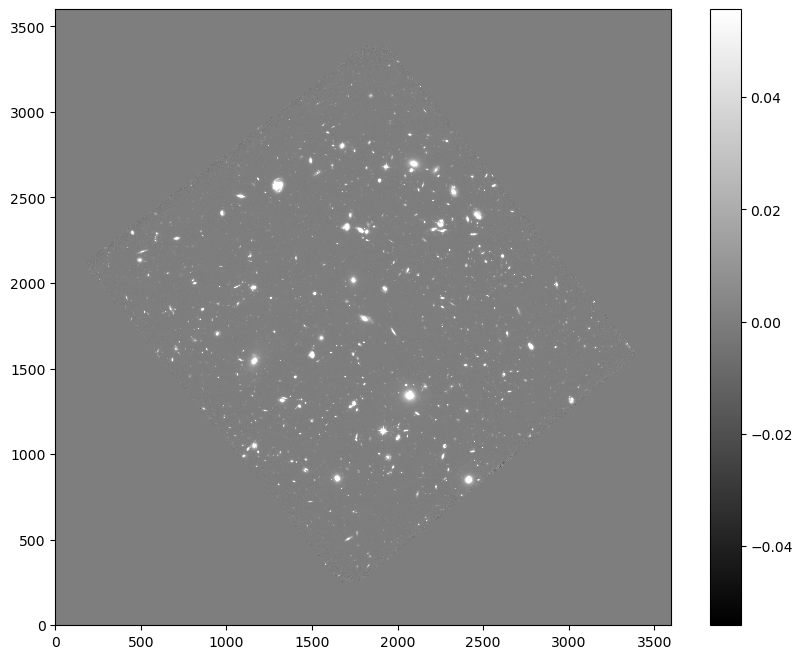

In [2]:
with fits.open("C:/Users/margo/hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits") as hdul:
    data = hdul[0].data

print(f"Datashape: {data.shape}, Data dimensions: {data.ndim}")

m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.show()

### Subtracting Background Data

0.0
0.0005398219218477607
Datashape: (3600, 3600), Data dimensions: 2


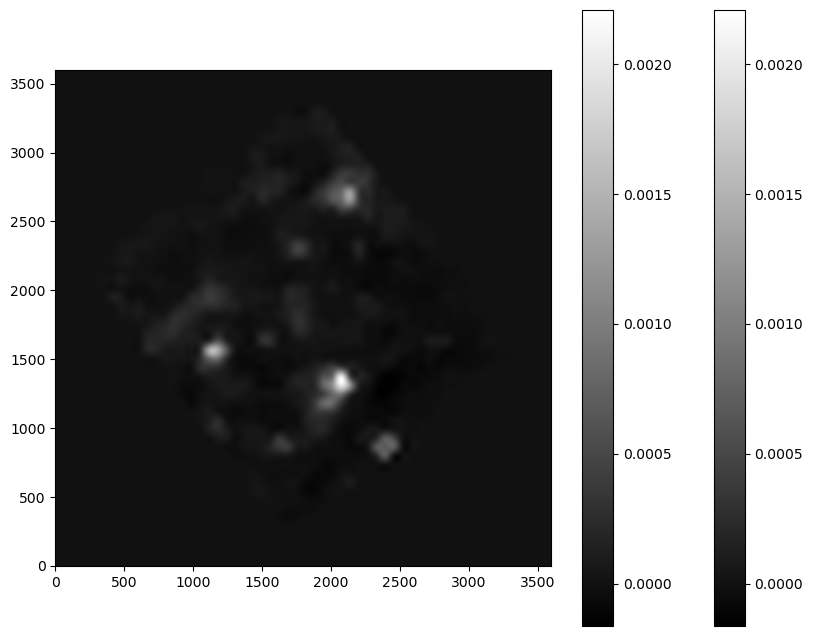

In [3]:
# Copy data to a new array, preserving the order of the oriignal array
new_data = data.astype(data.dtype.newbyteorder("="))

bkg = sep.Background(data = data.astype(data.dtype.newbyteorder("=")))

# get a "global" mean and noise of the image background
print(bkg.globalback)
print(bkg.globalrms)

print(f"Datashape: {data.shape}, Data dimensions: {data.ndim}")

# evaluate background as 2-d array
bkg_image = bkg.back()

# show background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar()
bkg_rms = bkg.rms()
plt.colorbar()

### Object Detection

Number of detected objects: 276
Detecting on background-subtracted image with shape: (3600, 3600)


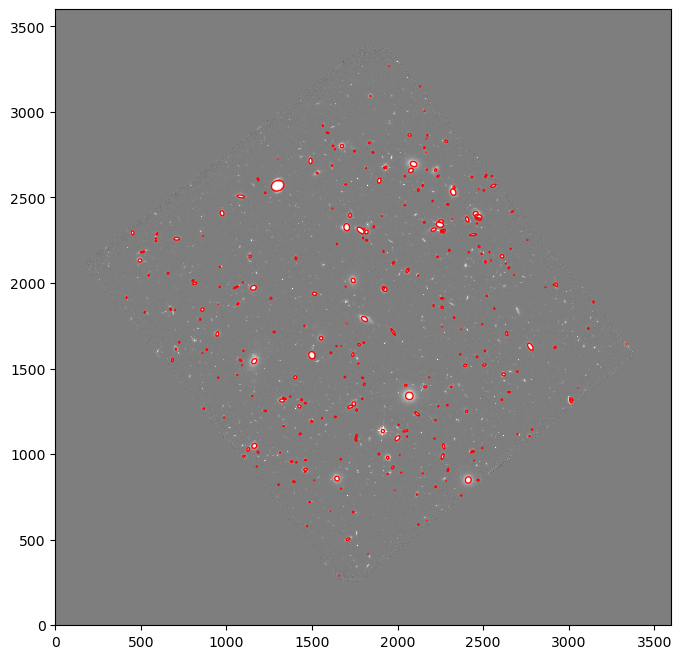

In [5]:
data_sub = new_data - bkg.back()
objects = sep.extract(data_sub, 0.05)

#How many objects were detected
len(objects)

from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m,s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin = m - s, vmax = m + s, origin = 'lower')

#Plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)
print(f"Number of detected objects: {len(objects)}")
print("Detecting on background-subtracted image with shape:", data_sub.shape)

### Aperture Photometry

In [6]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 1.145422 +/- 1.070248
object 1: flux = 1.252383 +/- 1.119103
object 2: flux = 3.206692 +/- 1.790726
object 3: flux = 1.421338 +/- 1.192202
object 4: flux = 2.248542 +/- 1.499517
object 5: flux = 1.215858 +/- 1.102663
object 6: flux = 8.206934 +/- 2.864776
object 7: flux = 1.291592 +/- 1.136486
object 8: flux = 1.474922 +/- 1.214467
object 9: flux = 1.930160 +/- 1.389305


### Analysis of Data

We found 276 sources in the data and plotted the first ten fluxes in a histogram.


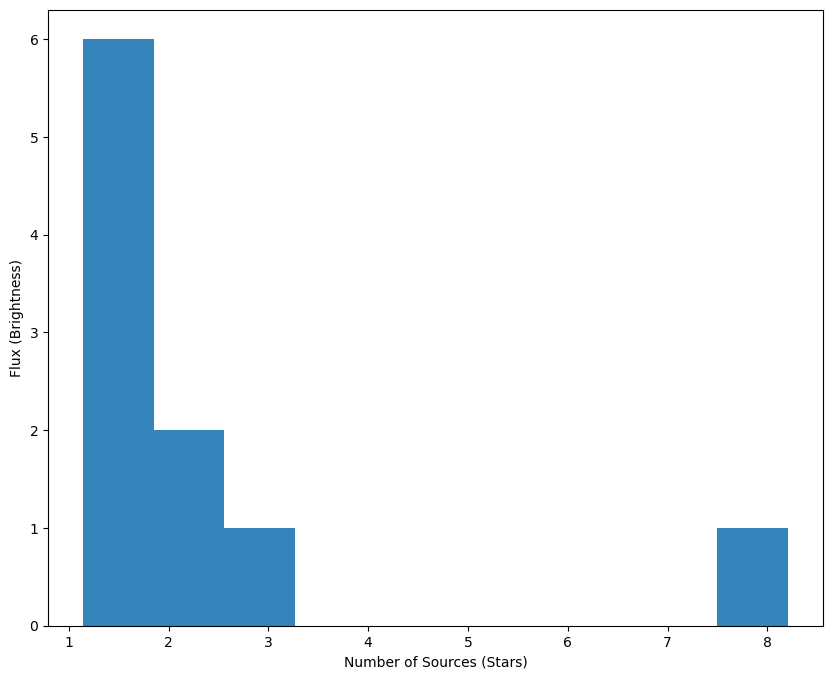

In [23]:
# How many sources do we find in the data?
# Histogram their fluxes

print("We found 276 sources in the data and plotted the first ten fluxes in a histogram.")
plt.hist(flux[:10],bins=10,alpha=0.9)
plt.xlabel('Number of Sources (Stars)')
plt.ylabel('Flux (Brightness)')
plt.savefig('flux.pdf')
plt.show()

In [22]:
mean_flux = np.mean(flux[:10])
median_flux = np.median(flux[:10])
std_flux = np.std(flux[:10])
max_flux = np.max(flux[:10])

# Print the results
print(f"Mean flux: {mean_flux}")
print(f"Median flux: {median_flux}")
print(f"Standard deviation: {std_flux}")
print(f"Max flux value on histogram: {max_flux}")

print(f"The maximum value is {(max_flux - mean_flux) / std_flux} standard deviations away from the mean")

Mean flux: 2.339384454954416
Median flux: 1.4481301743723456
Standard deviation: 2.047278280035003
Max flux value on histogram: 8.206934354603291
The maximum value is 2.8660245931728223 standard deviations away from the mean
